In [11]:
import numpy as np
import pandas as pd

In [16]:
from suncalc import get_position
from datetime import datetime

lat, lon = 48.1160859, 11.5349117

date = datetime.now()

In [2]:
get_position(date, lon, lat)

{'azimuth': np.float64(0.6741306521784407),
 'altitude': np.float64(0.9695670701641697)}

In [46]:
from wetterdienst.provider.dwd.mosmix import DwdMosmixRequest
import polars as pl

request = DwdMosmixRequest(
    parameters=[("hourly","small","radiation_global"),
                ("hourly","small","cloud_cover_effective"),
                ("hourly","small","sunshine_duration")],
)

values = request.filter_by_station_id(station_id=[10865]).values.query()
df = pl.concat([result.df for result in values])

In [47]:
df

station_id,resolution,dataset,parameter,date,value,quality
str,str,str,str,"datetime[μs, UTC]",f64,f64
"""10865""","""hourly""","""small""","""cloud_cover_effective""",2026-05-14 15:00:00 UTC,0.97,null
"""10865""","""hourly""","""small""","""cloud_cover_effective""",2026-05-14 16:00:00 UTC,0.99,null
"""10865""","""hourly""","""small""","""cloud_cover_effective""",2026-05-14 17:00:00 UTC,0.99,null
"""10865""","""hourly""","""small""","""cloud_cover_effective""",2026-05-14 18:00:00 UTC,1.0,null
"""10865""","""hourly""","""small""","""cloud_cover_effective""",2026-05-14 19:00:00 UTC,1.0,null
…,…,…,…,…,…,…
"""10865""","""hourly""","""small""","""sunshine_duration""",2026-05-24 10:00:00 UTC,3060.0,null
"""10865""","""hourly""","""small""","""sunshine_duration""",2026-05-24 11:00:00 UTC,2700.0,null
"""10865""","""hourly""","""small""","""sunshine_duration""",2026-05-24 12:00:00 UTC,2760.0,null


Text(0, 0.5, 'Value')

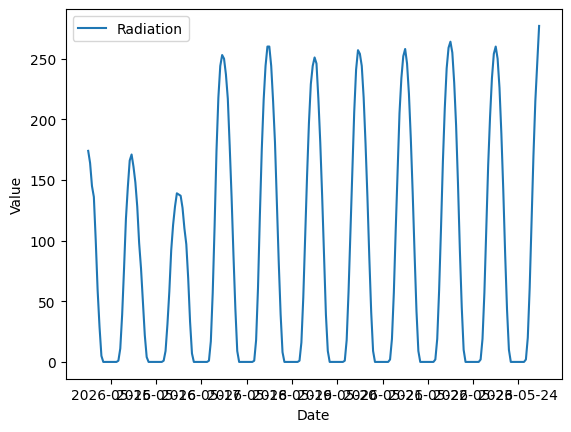

In [23]:
import matplotlib.pyplot as plt

plt.xlabel('Date')
df_radiation = df.filter(pl.col('parameter') == 'radiation_global')
df_cloud_cover = df.filter(pl.col('parameter') == 'cloud_cover_effective')
df_sunshine = df.filter(pl.col('parameter') == 'sunshine_duration')
plt.plot(df_radiation['date'], df_radiation['value'], label='Radiation')
# plt.plot(df_cloud_cover['date'], df_cloud_cover['value'], label='Cloud Cover')
# plt.plot(df_sunshine['date'], df_sunshine['value'], label='Sunshine Duration')
plt.legend()
plt.ylabel('Value')

In [6]:
def relative_radiation_on_panel(elevation_solar, azimuth_solar, tilt_panel, azimuth_panel):
    """
    Returns the cosine of the angle of incidence (0–1) of direct solar radiation on a panel.

    elevation_solar : sun altitude above horizon in radians (suncalc 'altitude')
    azimuth_solar   : sun azimuth from south, westward-positive in radians (suncalc 'azimuth')
    tilt_panel      : panel tilt from vertical in radians (0 = vertical, π/2 = horizontal)
    azimuth_panel   : panel facing direction from south, westward-positive in radians
    """
    tilt_from_horizontal = np.pi / 2 - tilt_panel
    azimuth_diff = azimuth_solar - azimuth_panel
    cos_aoi = (
        np.sin(elevation_solar) * np.cos(tilt_from_horizontal)
        + np.cos(elevation_solar) * np.sin(tilt_from_horizontal) * np.cos(azimuth_diff)
    )
    # Zero out when sun is below the horizon or behind the panel
    return np.maximum(cos_aoi, 0.0) * (elevation_solar > 0)

In [7]:
def balcony_geometry(elevation_solar, azimuthal_solar):
    # model geometry of solar panels on balcony: all vertically mounted,
    # two facing south, one facing east and west each
    panel_1 = relative_radiation_on_panel(elevation_solar, azimuthal_solar, 0, -np.pi/2)
    panels_23 = 2 * relative_radiation_on_panel(elevation_solar, azimuthal_solar, 0, 0)
    panel_4 = relative_radiation_on_panel(elevation_solar, azimuthal_solar, 0, np.pi/2)
    return (panel_1 + panels_23 + panel_4)/4

In [41]:
def irradiance_on_balcony(elevation, azimuth, ghi, sunshine_duration):
    """
    Returns actual irradiance [W/m²] on each panel orientation.

    elevation         : sun altitude above horizon (radians)
    azimuth           : sun azimuth from south, westward-positive (radians)
    ghi               : global horizontal irradiance in J/cm² for the hour
                        (wetterdienst normalises both MOSMIX kJ/m² and observations J/cm²
                         to J/cm²; convert to W/m² via × 10000/3600 ≈ × 2.778)
    sunshine_duration : seconds of direct sunshine in the hour (s)

    Diffuse model: isotropic sky + empirical horizon brightening (F2 ≈ 0.15 × sin β)
    Ground reflection: Lambertian albedo ≈ 0.2 (urban/suburban surface)

    Returns dict with keys 'east', 'south', 'west'.
    'south' is per panel; the layout has 2 south panels.
    """
    f_direct = sunshine_duration / 3600.0
    ghi_beam = ghi * f_direct
    ghi_diff = ghi * (1.0 - f_direct)

    # Clamp sin(elevation) to avoid R_b blowing up near the horizon.
    sin_elev = np.maximum(np.sin(elevation), np.sin(np.radians(5.0)))

    # J/cm² → W/m²:  1 J/cm² = 10000 J/m²;  averaged over 3600 s → × 10000/3600
    Jcm2_to_Wm2 = 10000.0 / 3600.0   # ≈ 2.778 W/m² per J/cm²
    ALBEDO = 0.2         # ground reflectivity (typical urban)
    HORIZON_BRIGHT = 0.15  # empirical Perez-style F2 horizon brightening coefficient

    def _panel(tilt, azimuth_panel):
        tilt_h = np.pi / 2 - tilt  # tilt from horizontal (π/2 for vertical panels)

        # ── Beam component ────────────────────────────────────────────────────
        cos_aoi = relative_radiation_on_panel(elevation, azimuth, tilt, azimuth_panel)
        R_b = cos_aoi / sin_elev
        g_beam = ghi_beam * R_b

        # ── Sky diffuse: isotropic + horizon brightening ───────────────────
        # Standard isotropic view factor: (1 + cos β) / 2
        #   vertical (β=90°) → 0.50, horizontal (β=0°) → 1.0
        # Perez F2 term adds horizon brightening: F2 × sin β
        #   vertical → +0.15; horizontal → 0 extra
        sky_view = (1 + np.cos(tilt_h)) / 2
        g_diff = ghi_diff * (sky_view + HORIZON_BRIGHT * np.sin(tilt_h))

        # ── Ground reflection ──────────────────────────────────────────────
        # Ground view factor: (1 − cos β) / 2  →  0.5 for vertical, 0 for horizontal
        g_refl = ghi * ALBEDO * (1 - np.cos(tilt_h)) / 2

        return (g_beam + g_diff + g_refl) * Jcm2_to_Wm2

    return {
        'east':  _panel(0, -np.pi / 2),
        'south': _panel(0,  0),
        'west':  _panel(0,  np.pi / 2),
    }

In [42]:
def balcony_power(elevation, azimuth, ghi, sunshine_duration, p_rated=225):
    """
    Returns total electric power [W] of all four balcony panels.

    p_rated : rated power per panel at STC (1000 W/m²), default 225 Wp.
    Panel layout: 1 east + 2 south + 1 west.
    """
    G_STC = 1000.0  # W/m² at standard test conditions
    irr = irradiance_on_balcony(elevation, azimuth, ghi, sunshine_duration)
    return p_rated / G_STC * (irr['east'] + 2 * irr['south'] + irr['west'])

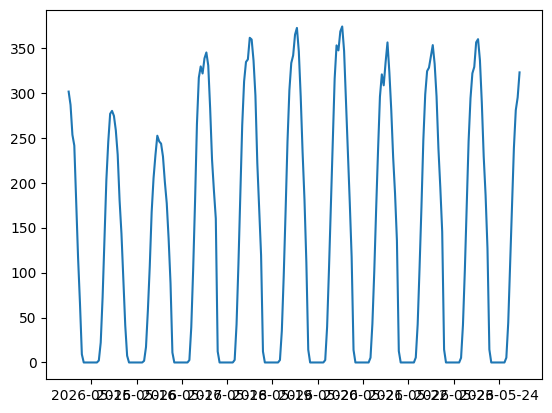

In [43]:
timestamps = df_radiation['date']
positions  = [get_position(t, lon, lat) for t in timestamps]
elevations = np.array([p['altitude'] for p in positions])
azimuths   = np.array([p['azimuth']  for p in positions])

plt.plot(timestamps, balcony_power(elevations, azimuths, df_radiation['value'], df_sunshine['value']))

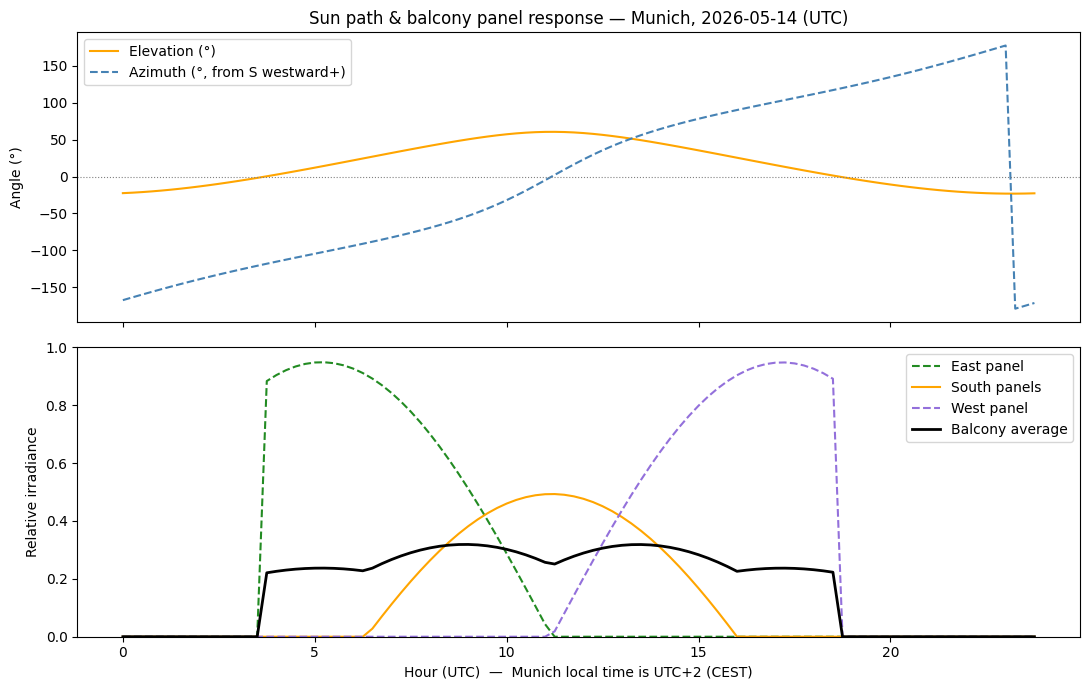

In [44]:
from datetime import date, datetime, timezone

# 15-minute timestamps over today in UTC
today = datetime.now(timezone.utc).date()
timestamps = [
    datetime(today.year, today.month, today.day, h, m, tzinfo=timezone.utc)
    for h in range(24) for m in range(0, 60, 15)
]
hours_utc = np.array([t.hour + t.minute / 60 for t in timestamps])

positions  = [get_position(t, lon, lat) for t in timestamps]
elevations = np.array([p['altitude'] for p in positions])
azimuths   = np.array([p['azimuth']  for p in positions])

# Individual panel responses for geometry verification
panel_east  = relative_radiation_on_panel(elevations, azimuths, 0, -np.pi / 2)
panel_south = relative_radiation_on_panel(elevations, azimuths, 0,  0)
panel_west  = relative_radiation_on_panel(elevations, azimuths, 0,  np.pi / 2)
panel_avg   = balcony_geometry(elevations, azimuths)

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

# ── Sun path ──────────────────────────────────────────────────────────────────
axes[0].plot(hours_utc, np.degrees(elevations), color='orange',    label='Elevation (°)')
axes[0].plot(hours_utc, np.degrees(azimuths),   color='steelblue', linestyle='--', label='Azimuth (°, from S westward+)')
axes[0].axhline(0, color='gray', linewidth=0.8, linestyle=':')
axes[0].set_ylabel('Angle (°)')
axes[0].set_title(f'Sun path & balcony panel response — Munich, {today} (UTC)')
axes[0].legend()

# ── Panel responses ───────────────────────────────────────────────────────────
axes[1].plot(hours_utc, panel_east,  color='forestgreen',  linestyle='--', label='East panel')
axes[1].plot(hours_utc, panel_south, color='orange',                        label='South panels')
axes[1].plot(hours_utc, panel_west,  color='mediumpurple', linestyle='--', label='West panel')
axes[1].plot(hours_utc, panel_avg,   color='black', linewidth=2,            label='Balcony average')
axes[1].set_xlabel('Hour (UTC)  —  Munich local time is UTC+2 (CEST)')
axes[1].set_ylabel('Relative irradiance')
axes[1].set_ylim(0, 1)
axes[1].legend()

plt.tight_layout()
plt.show()

In [48]:
from datetime import timezone

# ── Current-hour estimate (compare to inverter reading) ───────────────────────
now_utc = datetime.now(timezone.utc).replace(minute=0, second=0, microsecond=0)

def _get_row(param, ts):
    rows = df.filter(
        (pl.col('parameter') == param) &
        (pl.col('date') == ts)
    )
    return rows['value'][0] if len(rows) else None

now_ghi = _get_row('radiation_global',  now_utc)
now_sun = _get_row('sunshine_duration', now_utc)
if now_ghi is not None:
    pos_now = get_position(now_utc, lon, lat)
    irr_now = irradiance_on_balcony(pos_now['altitude'], pos_now['azimuth'], now_ghi, now_sun or 0)
    pwr_now = balcony_power(pos_now['altitude'], pos_now['azimuth'], now_ghi, now_sun or 0)
    print(f"Current hour ({now_utc}):")
    print(f"  GHI forecast : {now_ghi:.1f} J/cm²  = {now_ghi * 10000/3600:.1f} W/m²")
    print(f"  Sunshine     : {now_sun or 0:.0f} s/h  →  f_direct = {(now_sun or 0)/3600:.2f}")
    print(f"  East panel   : {irr_now['east']:.1f} W/m²")
    print(f"  South panel  : {irr_now['south']:.1f} W/m²  (×2)")
    print(f"  West panel   : {irr_now['west']:.1f} W/m²")
    print(f"  Total power  : {pwr_now:.1f} W   ← compare to inverter")
else:
    print(f"No forecast row found for {now_utc} — re-run the request cell first.")

# ── Peak GHI hour in the forecast ─────────────────────────────────────────────
df_rad = df.filter(pl.col('parameter') == 'radiation_global')
ghi_max_Wm2 = df_rad['value'].max() * 10000 / 3600
print(f"\nradiation_global range: {df_rad['value'].min():.1f} / {df_rad['value'].median():.1f} / {df_rad['value'].max():.1f} J/cm²")
print(f"  = {df_rad['value'].min()*10000/3600:.0f} / {df_rad['value'].median()*10000/3600:.0f} / {ghi_max_Wm2:.0f}  W/m²")

peak_row = df_rad.filter(pl.col('value') == df_rad['value'].max()).row(0, named=True)
peak_ts  = peak_row['date'].replace(tzinfo=timezone.utc)
peak_ghi = peak_row['value']
peak_sun = df.filter(
    (pl.col('parameter') == 'sunshine_duration') &
    (pl.col('date') == peak_row['date'])
)['value'][0]

pos_peak       = get_position(peak_ts, lon, lat)
elev_p, azim_p = pos_peak['altitude'], pos_peak['azimuth']
irr_peak       = irradiance_on_balcony(elev_p, azim_p, peak_ghi, peak_sun)
pwr_peak       = balcony_power(elev_p, azim_p, peak_ghi, peak_sun)
print(f"\nPeak GHI hour: {peak_ts}")
print(f"  GHI={peak_ghi:.1f} J/cm² = {peak_ghi*10000/3600:.0f} W/m²  SD={peak_sun:.0f} s  "
      f"elevation={np.degrees(elev_p):.1f}°  azimuth={np.degrees(azim_p):.1f}°")
print(f"  East panel  : {irr_peak['east']:.1f} W/m²")
print(f"  South panel : {irr_peak['south']:.1f} W/m²  (×2)")
print(f"  West panel  : {irr_peak['west']:.1f} W/m²")
print(f"  Total power : {pwr_peak:.1f} W")

No forecast row found for 2026-05-14 14:00:00+00:00 — re-run the request cell first.

radiation_global range: 0.0 / 43.5 / 285.0 J/cm²
  = 0 / 121 / 792  W/m²

Peak GHI hour: 2026-05-24 12:00:00+00:00
  GHI=285.0 J/cm² = 792 W/m²  SD=2760 s  elevation=60.9°  azimuth=24.1°
  East panel  : 199.2 W/m²
  South panel : 507.6 W/m²  (×2)
  West panel  : 337.2 W/m²
  Total power : 349.1 W


In [49]:
from wetterdienst.provider.dwd.observation import DwdObservationRequest
from datetime import datetime, timezone, timedelta

# Nearest solar observation station to Munich: 05404 Weihenstephan-Duernast (~34 km)
# DWD publishes hourly solar data with a lag of ~1-2 weeks.
# Use a safe window ending ~10 days ago.
end_obs   = datetime.now(timezone.utc) - timedelta(days=10)
start_obs = end_obs - timedelta(days=30)

req_obs = DwdObservationRequest(
    parameters=[
        ('hourly', 'solar', 'radiation_global'),
        ('hourly', 'solar', 'radiation_sky_short_wave_diffuse'),
        ('hourly', 'solar', 'sunshine_duration'),
    ],
    start_date=start_obs,
    end_date=end_obs,
)
# generator pattern — same as MOSMIX
obs_vals = req_obs.filter_by_station_id(station_id=['05404']).values.query()
df_obs = pl.concat([r.df for r in obs_vals])
print('Observation parameters:', df_obs['parameter'].unique().to_list())
print('Date range:', df_obs['date'].min(), '→', df_obs['date'].max())

# Unit: wetterdienst returns J/cm² for both radiation parameters
# Convert to W/m²: × 10000/3600 ≈ × 2.778
Jcm2_to_Wm2 = 10000 / 3600

ghi_obs  = df_obs.filter(pl.col('parameter') == 'radiation_global').select(['date','value']).rename({'value':'ghi_Jcm2'})
diff_obs = df_obs.filter(pl.col('parameter') == 'radiation_sky_short_wave_diffuse').select(['date','value']).rename({'value':'diff_Jcm2'})
sun_obs  = df_obs.filter(pl.col('parameter') == 'sunshine_duration').select(['date','value']).rename({'value':'sun_s'})

df_obs_wide = ghi_obs.join(diff_obs, on='date', how='left').join(sun_obs, on='date', how='left')
df_obs_wide = df_obs_wide.with_columns([
    (pl.col('ghi_Jcm2')  * Jcm2_to_Wm2).alias('ghi_Wm2'),
    (pl.col('diff_Jcm2') * Jcm2_to_Wm2).alias('diff_Wm2'),
])

print('\nTop observed GHI hours:')
print(df_obs_wide.sort('ghi_Wm2', descending=True).head(5).select(
    ['date','ghi_Wm2','diff_Wm2','sun_s']).to_pandas().to_string())

Observation parameters: ['sunshine_duration', 'radiation_global', 'radiation_sky_short_wave_diffuse']
Date range: 2026-04-04 15:00:00+00:00 → 2026-04-30 23:00:00+00:00

Top observed GHI hours:
                       date     ghi_Wm2    diff_Wm2   sun_s
0 2026-04-17 12:00:00+00:00  913.888889  213.888889  3600.0
1 2026-04-30 11:00:00+00:00  908.333333   75.000000  3600.0
2 2026-04-30 12:00:00+00:00  905.555556   75.000000  3600.0
3 2026-04-27 12:00:00+00:00  902.777778  216.666667  3600.0
4 2026-04-24 12:00:00+00:00  894.444444   80.555556  3600.0


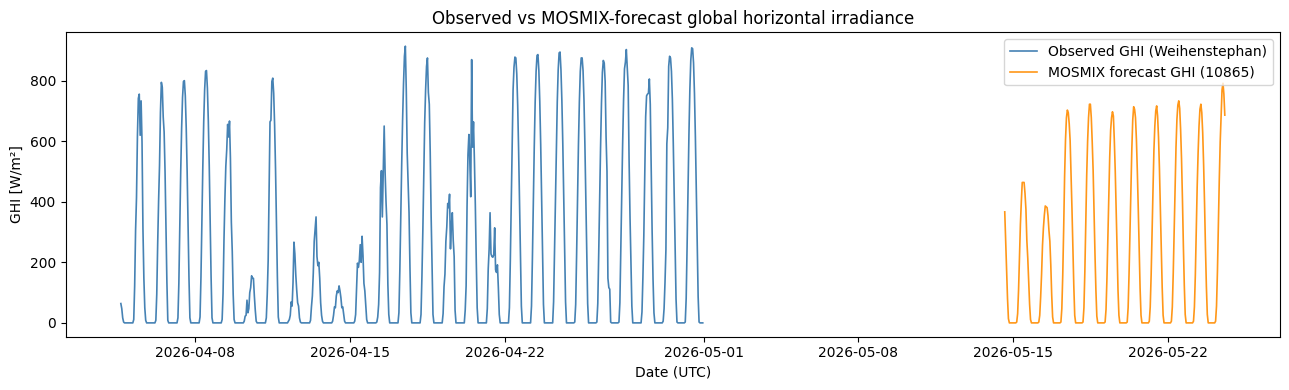

Observed daily GHI totals [kWh/m²/day] — last 10 days with data:
         day  kWh_m2_day
0 2026-04-21    2.713889
1 2026-04-22    7.358333
2 2026-04-23    7.430556
3 2026-04-24    7.533333
4 2026-04-25    7.463889
5 2026-04-26    6.852778
6 2026-04-27    7.413889
7 2026-04-28    6.425000
8 2026-04-29    7.175000
9 2026-04-30    7.880556


In [50]:
# ── Compare MOSMIX forecast GHI vs observed GHI over the observation window ──
# MOSMIX df starts at today; observation df covers the past ~2-4 weeks.
# We can only compare dates that appear in BOTH (MOSMIX starts from today, so
# overlap requires the MOSMIX window to reach back — with the current run it won't).
# Instead we plot both series to visually see forecast skill for the overlap,
# and compute daily totals to compare against independent energy predictions.

Jcm2_to_Wm2 = 10000 / 3600   # J/cm²/h → W/m² (hourly average)

df_mosmix_ghi = (
    df.filter(pl.col('parameter') == 'radiation_global')
    .select(['date','value'])
    .rename({'value':'ghi_Jcm2'})
    .with_columns((pl.col('ghi_Jcm2') * Jcm2_to_Wm2).alias('ghi_Wm2'))
)

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(df_obs_wide['date'], df_obs_wide['ghi_Wm2'],
        color='steelblue', linewidth=1.2, label='Observed GHI (Weihenstephan)')
ax.plot(df_mosmix_ghi['date'], df_mosmix_ghi['ghi_Wm2'],
        color='darkorange', linewidth=1.2, alpha=0.9, label='MOSMIX forecast GHI (10865)')
ax.set_ylabel('GHI [W/m²]')
ax.set_xlabel('Date (UTC)')
ax.set_title('Observed vs MOSMIX-forecast global horizontal irradiance')
ax.legend()
plt.tight_layout()
plt.show()

# Daily totals: kWh/m²/day = sum(ghi_Jcm2) * 10000/3600 / 1000
obs_daily = (
    df_obs_wide.with_columns(pl.col('date').dt.date().alias('day'))
    .group_by('day').agg((pl.col('ghi_Jcm2').sum() * 10000/3600/1000).alias('kWh_m2_day'))
    .sort('day')
)
print('Observed daily GHI totals [kWh/m²/day] — last 10 days with data:')
print(obs_daily.tail(10).to_pandas().to_string())